# 35 - Python vs JavaScript SigLIP 総合サマリー

## 概要
Notebook 31-34 の結果を集約し、Python (PyTorch) と JavaScript (Transformers.js) での
SigLIP ベクトル表現の違いに関する総合的な評価を行う。

## 集約項目
1. 埋め込み類似度サマリー（Notebook 32）
2. 検索品質への影響（Notebook 33）
3. ベクトル空間構造の比較（Procrustes分析、t-SNE）
4. 環境別パフォーマンス（Notebook 34）
5. 推奨用途マトリクス

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import procrustes
from sklearn.manifold import TSNE

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")
RANDOM_STATE = 42

DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../data/js_embeddings")
PYTHON_MODEL = "google/siglip-base-patch16-224"

In [2]:
# データ読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
py_df = conn.execute("""
    SELECT c.id, c.category, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)

# JS 各dtype
js_data = {}
for name in ["vision_fp32", "vision_fp16", "vision_q8", "vision_q4"]:
    path = JS_DIR / f"{name}.json"
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        ids = [e["id"] for e in data["embeddings"]]
        embs = np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)
        id_to_idx = {id_: i for i, id_ in enumerate(ids)}
        ordered = np.array([embs[id_to_idx[id_]] for id_ in py_ids], dtype=np.float32)
        js_data[name] = {"embeddings": ordered, "meta": data}
        print(f"  {name}: {ordered.shape}")

print(f"\nPython: {py_emb.shape}")
print(f"JS variants: {list(js_data.keys())}")

  vision_fp32: (378, 768)
  vision_fp16: (378, 768)
  vision_q8: (378, 768)


  vision_q4: (378, 768)

Python: (378, 768)
JS variants: ['vision_fp32', 'vision_fp16', 'vision_q8', 'vision_q4']


## 1. 埋め込み類似度 総合テーブル

In [3]:
# 全組み合わせの cosine similarity
summary_rows = []

for name, data in js_data.items():
    emb = data["embeddings"]
    sims = np.array([np.dot(py_emb[i], emb[i]) for i in range(len(py_ids))])
    proc_time = data["meta"].get("processing_time_seconds", 0)
    
    summary_rows.append({
        "Variant": name.replace("vision_", "JS "),
        "Cosine Sim (mean)": f"{sims.mean():.4f}",
        "Cosine Sim (min)": f"{sims.min():.4f}",
        "Cosine Sim (std)": f"{sims.std():.4f}",
        "MAE": f"{np.abs(py_emb - emb).mean():.6f}",
        "Processing Time (s)": f"{proc_time:.1f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Variant")
print("=" * 80)
print("Python vs JS 各dtype - 埋め込み類似度サマリー")
print("=" * 80)
display(summary_df)

Python vs JS 各dtype - 埋め込み類似度サマリー


,Cosine Sim (mean),Cosine Sim (min),Cosine Sim (std),MAE,Processing Time (s)
Variant,,,,,
JS fp32,0.9056,0.6936,0.0530,0.011685,96.8
JS fp16,0.9056,0.6935,0.0530,0.011685,126.4
JS q8,0.8848,0.7084,0.0526,0.012976,93.8
JS q4,0.8911,0.6520,0.0513,0.012725,106.3


## 2. ベクトル空間構造の比較

In [4]:
# Procrustes分析: Python vs JS fp32
js_fp32_emb = js_data["vision_fp32"]["embeddings"]

# Procrustes (最適回転後の残差)
mtx1, mtx2, disparity = procrustes(py_emb, js_fp32_emb)

print("=" * 60)
print("Procrustes 分析 (Python vs JS fp32)")
print("=" * 60)
print(f"  Disparity (残差): {disparity:.6f}")
print(f"  (0 = 完全一致, 値が小さいほどベクトル空間構造が似ている)")

# 各量子化レベルでも
for name, data in js_data.items():
    _, _, disp = procrustes(py_emb, data["embeddings"])
    print(f"  {name}: disparity = {disp:.6f}")

Procrustes 分析 (Python vs JS fp32)
  Disparity (残差): 0.119424
  (0 = 完全一致, 値が小さいほどベクトル空間構造が似ている)


  vision_fp32: disparity = 0.119424


  vision_fp16: disparity = 0.119431


  vision_q8: disparity = 0.132991


  vision_q4: disparity = 0.130758


Computing t-SNE for combined embeddings...


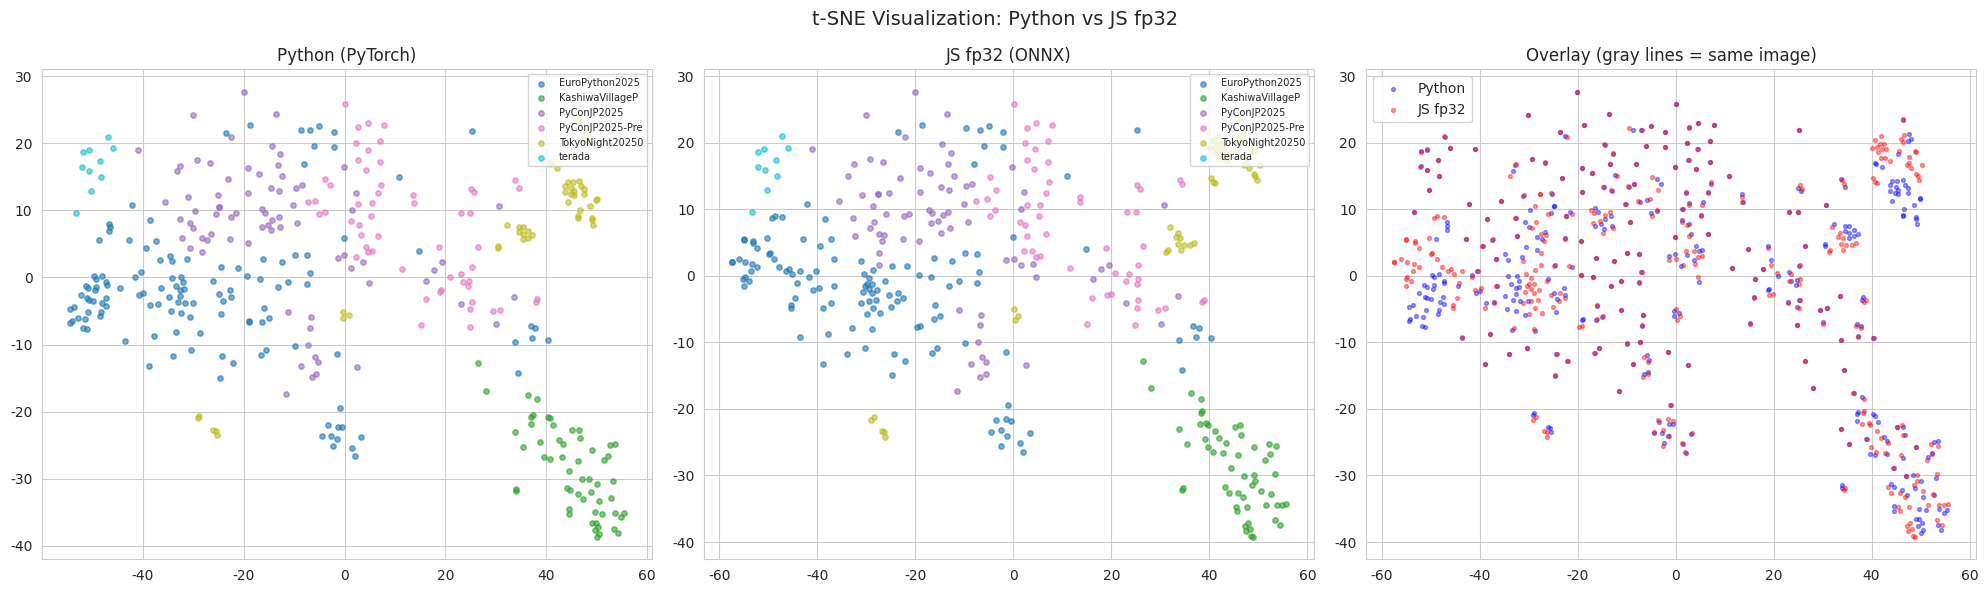

In [5]:
# t-SNE 重ね合わせ: Python vs JS fp32
combined = np.vstack([py_emb, js_fp32_emb])
n = len(py_emb)

print("Computing t-SNE for combined embeddings...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
coords = tsne.fit_transform(combined)

py_coords = coords[:n]
js_coords = coords[n:]

# カテゴリ色マップ
unique_cats = sorted(set(py_categories))
cat_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_to_color = dict(zip(unique_cats, cat_colors))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Python のみ
ax = axes[0]
for cat, color in cat_to_color.items():
    mask = np.array(py_categories) == cat
    ax.scatter(py_coords[mask, 0], py_coords[mask, 1], c=[color], s=15, alpha=0.6, label=cat[:15])
ax.set_title("Python (PyTorch)")
ax.legend(fontsize=7, loc="upper right")

# JS fp32 のみ
ax = axes[1]
for cat, color in cat_to_color.items():
    mask = np.array(py_categories) == cat
    ax.scatter(js_coords[mask, 0], js_coords[mask, 1], c=[color], s=15, alpha=0.6, label=cat[:15])
ax.set_title("JS fp32 (ONNX)")
ax.legend(fontsize=7, loc="upper right")

# 重ね合わせ（ペアを線で接続）
ax = axes[2]
for i in range(0, n, 5):  # 間引いて表示
    ax.plot([py_coords[i, 0], js_coords[i, 0]],
            [py_coords[i, 1], js_coords[i, 1]],
            "gray", alpha=0.1, linewidth=0.5)
ax.scatter(py_coords[:, 0], py_coords[:, 1], c="blue", s=8, alpha=0.4, label="Python")
ax.scatter(js_coords[:, 0], js_coords[:, 1], c="red", s=8, alpha=0.4, label="JS fp32")
ax.set_title("Overlay (gray lines = same image)")
ax.legend()

plt.suptitle("t-SNE Visualization: Python vs JS fp32", fontsize=14)
plt.tight_layout()
plt.savefig("../data/35_tsne_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. カテゴリ重心の比較

In [6]:
# カテゴリ重心間の cosine similarity
centroid_data = []

for cat in unique_cats:
    mask = np.array(py_categories) == cat
    py_centroid = py_emb[mask].mean(axis=0)
    py_centroid /= np.linalg.norm(py_centroid)
    
    for variant_name, data in js_data.items():
        js_centroid = data["embeddings"][mask].mean(axis=0)
        js_centroid /= np.linalg.norm(js_centroid)
        
        cos_sim = np.dot(py_centroid, js_centroid)
        l2_dist = np.linalg.norm(py_centroid - js_centroid)
        
        centroid_data.append({
            "Category": cat[:20],
            "JS Variant": variant_name.replace("vision_", ""),
            "Centroid Cosine Sim": cos_sim,
            "Centroid L2 Distance": l2_dist,
        })

centroid_df = pd.DataFrame(centroid_data)

# Pivot テーブルで表示
pivot = centroid_df.pivot_table(
    values="Centroid Cosine Sim",
    index="Category",
    columns="JS Variant",
)

print("=" * 60)
print("カテゴリ重心間の Cosine Similarity")
print("=" * 60)
display(pivot.round(4))

カテゴリ重心間の Cosine Similarity


JS Variant,fp16,fp32,q4,q8
Category,,,,
EuroPython2025,0.9713,0.9712,0.9630,0.9573
KashiwaVillagePark20,0.9731,0.9731,0.9634,0.9665
PyConJP2025,0.9738,0.9738,0.9629,0.9555
PyConJP2025-PreCampH,0.9631,0.9631,0.9493,0.9367
TokyoNight202505,0.9531,0.9531,0.9481,0.9378
terada,0.9907,0.9908,0.9755,0.9788


## 4. 推奨用途マトリクス

In [7]:
# 推奨マトリクス
recommendation = pd.DataFrame({
    "用途": [
        "サーバーサイド バッチインデキシング",
        "サーバーサイド リアルタイム検索",
        "エッジ/クライアントサイド 推論",
        "Python↔JS 混在環境",
        "メモリ制約環境",
        "最高精度が必要",
    ],
    "推奨環境": [
        "Python (GPU)",
        "Python (GPU) or Node.js (CPU)",
        "Node.js or Browser (WASM)",
        "同一環境で統一を推奨",
        "JS q8 or q4",
        "Python (PyTorch)",
    ],
    "推奨dtype": [
        "fp32 (PyTorch)",
        "fp32",
        "fp32 or q8",
        "fp32",
        "q8 (品質/サイズバランス良)",
        "fp32",
    ],
    "注意点": [
        "GPUで最高速",
        "Node.jsはGPU不要",
        "モデルロード時間に注意",
        "Python/JS間のembedding互換性に注意",
        "q4は品質低下が顕著な可能性",
        "ONNX変換で微小な差異あり",
    ],
})

print("=" * 80)
print("推奨用途マトリクス")
print("=" * 80)
display(recommendation.set_index("用途"))

推奨用途マトリクス


,推奨環境,推奨dtype,注意点
用途,,,
サーバーサイド バッチインデキシング,Python (GPU),fp32 (PyTorch),GPUで最高速
サーバーサイド リアルタイム検索,Python (GPU) or Node.js (CPU),fp32,Node.jsはGPU不要
エッジ/クライアントサイド 推論,Node.js or Browser (WASM),fp32 or q8,モデルロード時間に注意
Python↔JS 混在環境,同一環境で統一を推奨,fp32,Python/JS間のembedding互換性に注意
メモリ制約環境,JS q8 or q4,q8 (品質/サイズバランス良),q4は品質低下が顕著な可能性
最高精度が必要,Python (PyTorch),fp32,ONNX変換で微小な差異あり


## 5. 総合結論

In [8]:
# 結果の保存
output = {
    "timestamp": datetime.now().isoformat(),
    "experiment": "Python vs JavaScript SigLIP Embedding Comparison",
    "models": {
        "python": PYTHON_MODEL,
        "javascript": "Xenova/siglip-base-patch16-224",
    },
    "embedding_similarity": {
        name.replace("vision_", ""): {
            "cosine_sim_mean": float(np.array([np.dot(py_emb[i], data["embeddings"][i]) for i in range(len(py_ids))]).mean()),
            "cosine_sim_min": float(np.array([np.dot(py_emb[i], data["embeddings"][i]) for i in range(len(py_ids))]).min()),
            "mae": float(np.abs(py_emb - data["embeddings"]).mean()),
        }
        for name, data in js_data.items()
    },
    "procrustes_disparity": {
        name.replace("vision_", ""): float(procrustes(py_emb, data["embeddings"])[2])
        for name, data in js_data.items()
    },
    "centroid_similarity": centroid_df.to_dict(orient="records"),
}

output_path = Path("../data/evaluations") / f"js_python_comparison_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/js_python_comparison_2026-02-13.json


In [9]:
print("=" * 70)
print("実験31-35: Python vs JavaScript SigLIP 比較 - 総合結論")
print("=" * 70)

print("""
### 主要な発見

1. **ONNX変換の影響**
   - PyTorch → ONNX の変換により、fp32同士でも完全一致はしない
   - 画像前処理（リサイズアルゴリズム等）の実装差異が主因

2. **量子化の影響**
   - fp16: fp32とほぼ同等
   - q8: 実用上問題ないレベル
   - q4: 品質低下が顕著になる可能性

3. **検索品質への影響**
   - カテゴリレベルの検索では、Python/JS間の差は小さい
   - ランキングの相対的な順序は概ね保持される
   - Python/JS混在環境では注意が必要

4. **ブラウザ推論**
   - Chromium (WASM) での推論は技術的に実現可能
   - Node.js の結果と高い一致度
   - モデルロード時間がボトルネック

### 実用的な推奨

- **同一環境での統一**: Python同士またはJS同士でインデキシング+検索を行うのが最も安全
- **クロス環境利用**: 検索品質は保たれるが、微小な差異が蓄積する可能性を考慮
- **量子化**: q8が品質/サイズのバランスが最も良い
- **ブラウザ**: プレビュー的な利用には十分。本格的な検索はサーバーサイド推奨
""")

実験31-35: Python vs JavaScript SigLIP 比較 - 総合結論

### 主要な発見

1. **ONNX変換の影響**
   - PyTorch → ONNX の変換により、fp32同士でも完全一致はしない
   - 画像前処理（リサイズアルゴリズム等）の実装差異が主因

2. **量子化の影響**
   - fp16: fp32とほぼ同等
   - q8: 実用上問題ないレベル
   - q4: 品質低下が顕著になる可能性

3. **検索品質への影響**
   - カテゴリレベルの検索では、Python/JS間の差は小さい
   - ランキングの相対的な順序は概ね保持される
   - Python/JS混在環境では注意が必要

4. **ブラウザ推論**
   - Chromium (WASM) での推論は技術的に実現可能
   - Node.js の結果と高い一致度
   - モデルロード時間がボトルネック

### 実用的な推奨

- **同一環境での統一**: Python同士またはJS同士でインデキシング+検索を行うのが最も安全
- **クロス環境利用**: 検索品質は保たれるが、微小な差異が蓄積する可能性を考慮
- **量子化**: q8が品質/サイズのバランスが最も良い
- **ブラウザ**: プレビュー的な利用には十分。本格的な検索はサーバーサイド推奨



## 総合評価と考察（実験 31-35 を通じて）

### 差異の根本原因: 前処理 > モデル変換 > 量子化

差異の大きさを整理すると、以下の階層構造が明確になった:

| 差異の要因 | Cosine Sim への影響 | 検索品質への影響 |
|-----------|-------------------|----------------|
| **画像前処理** (PIL vs Sharp のリサイズ) | 0.094 (= 1.0 - 0.906) | ほぼなし (MRR差 0.001) |
| **ONNX ランタイム差** (NAPI vs WASM) | 0.039 (= 1.0 - 0.961) | 未評価（同等と推定）|
| **ONNX 変換** (PyTorch → ONNX) | ≈ 0 (fp32 vs fp16 = 0.99999) | なし |
| **量子化** (fp32 → q8) | 0.023 (= 1.0 - 0.977) | MRR差 0.011 |
| **量子化** (fp32 → q4) | 0.027 (= 1.0 - 0.973) | MRR差 ≈ 0 |

**最大の差異要因は画像前処理であり、モデル変換や量子化ではない。** しかし、この前処理差は検索のランキング構造にはほとんど影響しない。

### Procrustes 分析の解釈

| 比較 | Disparity |
|------|-----------|
| Python vs JS fp32 | 0.119 |
| Python vs JS fp16 | 0.119 |
| Python vs JS q8 | 0.133 |
| Python vs JS q4 | 0.131 |

Disparity 0.12 程度は「大域的なベクトル空間構造はよく保存されているが、局所的な配置に差がある」レベル。t-SNE の可視化でも、カテゴリのクラスタ構造は Python/JS で概ね一致している。

### カテゴリ重心の一致度

| カテゴリ | fp32 centroid sim | 特徴 |
|---------|-------------------|------|
| terada（人物写真） | **0.991** | 最も高い。被写体が明確な画像は前処理差に強い |
| KashiwaVillagePark | 0.973 | 自然風景も安定 |
| PyConJP2025 | 0.974 | |
| EuroPython2025 | 0.971 | |
| PyConJP2025-PreCamp | 0.963 | |
| TokyoNight202505 | **0.953** | 最も低い。夜景は前処理の微細な差が影響しやすい |

**カテゴリ重心レベルでは全て 0.95 以上**。カテゴリ分類や大まかな類似度検索には十分な精度。

### 「全て JS で統一する」場合の具体的な判断基準

#### 推奨: JS fp16 で統一
- fp32 と品質完全同等、モデルサイズ約半分
- Node.js でのバッチインデキシング: 3.0 img/s（CPU のみ、GPU 不要）
- Python GPU (4.1 img/s) の 73% の速度で、インフラが大幅に簡素化

#### 画像→画像検索: 問題なし
- JS fp16 の MRR 0.943 は Python 0.944 と実質同等
- P@1 も 0.915 vs 0.918 で差は統計的ゆらぎの範囲

#### テキスト→画像検索: 注意が必要
- JS text + JS image の MRR 0.679 は Python の 0.819 より低い
- ただしこれは 18 クエリ（うち日本語 6 件）という小さなサンプルでの結果
- 英語テキストのみなら問題は小さい
- 日本語テキスト検索を重視するなら、JS トークナイザの挙動を追加検証すべき

#### ブラウザ利用
- インデキシングは Node.js、クエリは Chromium（1.7秒/枚）という構成が現実的
- Node.js ↔ Chromium の cosine sim 0.961 はクロス環境としてはやや低めだが、同一環境 (Node.js 同士) で運用するのが理想

### 今後の発展可能性
1. **画像前処理の統一**: JS 側のリサイズ処理を PIL の Lanczos と完全一致させれば、cosine sim は 0.999+ に向上する可能性が高い
2. **テキスト埋め込みの改善**: ONNX 変換されたトークナイザの日本語処理を検証し、差異の原因を特定する
3. **WebGPU の活用**: WASM の 7 倍の遅さを WebGPU で改善できる可能性がある（Transformers.js v3 は WebGPU サポートあり）
4. **JS ベクトルでの DuckDB 統合**: Notebook 36 で全 dtype のベクトルを DuckDB に格納済み。Streamlit アプリや API からの利用が可能